## Import Library

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import os, json, pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.utils import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    Embedding, LSTM, GRU, Dense, Dropout,
    Bidirectional, GlobalMaxPool1D, Conv1D,
    MaxPooling1D, BatchNormalization, Flatten, GlobalAveragePooling1D,
)
from tensorflow.keras.callbacks import TensorBoard
import datetime
from collections import Counter
# Untuk custom layer nanti:
from tensorflow.keras.layers import Layer


### Inisiasi Nilai Konstanta

In [27]:
RANDOM_SEED   = 42
NUM_WORDS     = 10000
MAX_LENGTH    = 200
EMBED_DIM     = 128
EPOCH         = 50
BATCH_SIZE    = 32
OUTPUT_DIR = './models'
LOGS_DIR   = './logs'
DATSET_PATH = 'D:\\Kuliah\\DICODING\\Capstone\\HealMate_AI\\DS\\Empathetic Counseling Dataset\\Empathetic Counseling.xlsx'
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)
LOG_DIR = os.path.join(LOGS_DIR, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

## Load Dataset

In [28]:
df =pd.read_excel(DATSET_PATH)
print(f'Shape : {df.shape}')
df.head()

Shape : (1336, 10)


,input_clean,label_clean,input_no_punct,label_no_punct,breakup_score,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence
0,my fiance and i have been together for 3 years...,finding out about an affair is quite an emotio...,my fiance and i have been together for 3 years...,finding out about an affair is quite an emotio...,4,0.133414,0.597922,0.268664,anxiety,0.597922
1,i caught my wife red handed cheating on me i f...,i could not move my body. i fainted because sh...,i caught my wife red handed cheating on me i f...,i could not move my body i fainted because she...,2,0.576117,0.211942,0.211942,anger,0.576117
2,we live with my ex partners sister and her hus...,"hi new york, i am happy to hear that your daug...",we live with my ex partners sister and her hus...,hi new york i am happy to hear that your daugh...,2,0.576117,0.211942,0.211942,anger,0.576117
3,"hello, i have a cousin in my family who has be...",it sounds like you are feeling pretty criticiz...,hello i have a cousin in my family who has bee...,it sounds like you are feeling pretty criticiz...,2,0.785597,0.175290,0.039113,anger,0.785597
4,i am concerned about my current long distance ...,it is important to communicate your concerns w...,i am concerned about my current long distance ...,it is important to communicate your concerns w...,4,0.576117,0.211942,0.211942,anger,0.576117


## Exploratory Data Analysis

In [29]:
df.info()
print('\nMissing values:')
print(df.isnull().sum())
print(f'\nDuplikat : {df.duplicated().sum()}')
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   input_clean         1336 non-null   str    
 1   label_clean         1336 non-null   str    
 2   input_no_punct      1336 non-null   str    
 3   label_no_punct      1336 non-null   str    
 4   breakup_score       1336 non-null   int64  
 5   anger_prob          1336 non-null   float64
 6   anxiety_prob        1336 non-null   float64
 7   acceptance_prob     1336 non-null   float64
 8   predicted_emotion   1336 non-null   str    
 9   emotion_confidence  1336 non-null   float64
dtypes: float64(4), int64(1), str(5)
memory usage: 104.5 KB

Missing values:
input_clean           0
label_clean           0
input_no_punct        0
label_no_punct        0
breakup_score         0
anger_prob            0
anxiety_prob          0
acceptance_prob       0
predicted_emotion     0
emotion_confidence    0

,breakup_score,anger_prob,anxiety_prob,acceptance_prob,emotion_confidence
count,1336.000000,1336.000000,1336.000000,1336.000000,1336.000000
mean,2.448353,0.355560,0.347360,0.297081,0.545280
std,0.863941,0.191219,0.184883,0.168202,0.145423
min,2.000000,0.000335,0.000911,0.009368,0.344535
25%,2.000000,0.211942,0.211942,0.211942,0.451863
50%,2.000000,0.327732,0.344535,0.239694,0.576117
75%,3.000000,0.576117,0.451863,0.327732,0.576117
max,9.000000,0.979748,0.980098,0.998754,0.998754


In [30]:

#Distribusi panjang teks
df['input_length'] = df['input_clean'].str.split().str.len()
df['label_length'] = df['label_clean'].str.split().str.len()
print(df[['input_length', 'label_length']].describe())

#Cek duplikat input (input sama, label berbeda)
print(f"Input unik: {df['input_clean'].nunique()} dari {len(df)} total")

#Cek label noise (confidence rendah)
print(df[df['emotion_confidence'] < 0.5]['predicted_emotion'].value_counts())


       input_length  label_length
count   1336.000000   1336.000000
mean      62.889222    106.099551
std       65.403281    115.702096
min        4.000000      1.000000
25%       25.000000     22.000000
50%       48.000000     73.000000
75%       72.000000    142.250000
max      555.000000    949.000000
Input unik: 855 dari 1336 total
predicted_emotion
anxiety       347
anger          59
acceptance      1
Name: count, dtype: int64


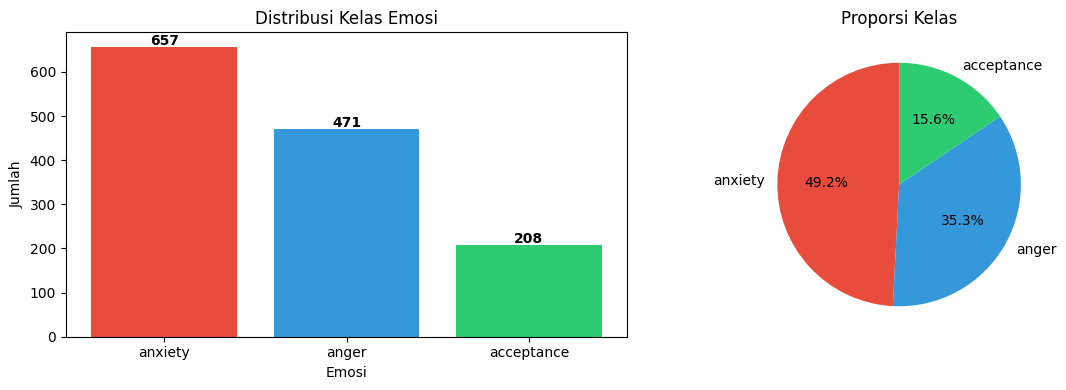

predicted_emotion
anxiety       657
anger         471
acceptance    208
Name: count, dtype: int64


In [31]:
# ── Distribusi Kelas ─────────────────────────────────────────
label_counts = df['predicted_emotion'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(label_counts.index, label_counts.values,
            color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('Distribusi Kelas Emosi')
axes[0].set_xlabel('Emosi')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=['#e74c3c', '#3498db', '#2ecc71'],
            startangle=90)
axes[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.show()
print(label_counts)

## Split Data

In [32]:
X = df['input_clean'].fillna('').astype(str)
y = df['predicted_emotion']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls:12s} → {i}')

with open(os.path.join(OUTPUT_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)
print("✅ Label encoder disimpan.")

Label encoding:
  acceptance   → 0
  anger        → 1
  anxiety      → 2
✅ Label encoder disimpan.


In [33]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_SEED, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)

print(f'\nData split:')
print(f'  Train set : {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Val set   : {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test set  : {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)')

print("Distribusi train:", Counter(y_train))
print("Distribusi val:  ", Counter(y_val))
print("Distribusi test: ", Counter(y_test))

# Simpan index train untuk mapping retrieval
train_indices = X_train.index.tolist()
print(f'\n✅ Index train disimpan untuk mapping retrieval ({len(train_indices)} baris)')


Data split:
  Train set : 1,068 samples (79.9%)
  Val set   : 134 samples (10.0%)
  Test set  : 134 samples (10.0%)
Distribusi train: Counter({np.int64(2): 525, np.int64(1): 377, np.int64(0): 166})
Distribusi val:   Counter({np.int64(2): 66, np.int64(1): 47, np.int64(0): 21})
Distribusi test:  Counter({np.int64(2): 66, np.int64(1): 47, np.int64(0): 21})

✅ Index train disimpan untuk mapping retrieval (1068 baris)


## Tokenisasi dan Padding

In [34]:
tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

vocab_size = min(len(tokenizer.word_index) + 1, NUM_WORDS)
print(f'Vocab size (aktual) : {len(tokenizer.word_index):,}')
print(f'Vocab size (capped) : {vocab_size:,}')

def texts_to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LENGTH, padding='post', truncating='post')

X_train_seq = texts_to_padded(X_train)
X_val_seq   = texts_to_padded(X_val)
X_test_seq  = texts_to_padded(X_test)

print(f'\nShape setelah padding:')
print(f'  Train : {X_train_seq.shape}')
print(f'  Val   : {X_val_seq.shape}')
print(f'  Test  : {X_test_seq.shape}')

with open(os.path.join(OUTPUT_DIR, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)
print("✅ Tokenizer disimpan.")

Vocab size (aktual) : 3,031
Vocab size (capped) : 3,032

Shape setelah padding:
  Train : (1068, 200)
  Val   : (134, 200)
  Test  : (134, 200)
✅ Tokenizer disimpan.


## Ekstraksi Fitur

### TF-IDF

In [35]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)
print(f'TF-IDF matrix shape: {X_train_tfidf.shape}')

smote_tfidf = SMOTE(random_state=RANDOM_SEED)
X_train_tfidf_smote, y_train_tfidf_smote = smote_tfidf.fit_resample(X_train_tfidf, y_train)

print('\nSMOTE TF-IDF — distribusi setelah resampling:')
unique, counts = np.unique(y_train_tfidf_smote, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f'  {cls:12s}: {cnt}')
print(f'  Total: {len(y_train_tfidf_smote):,}')

TF-IDF matrix shape: (1068, 3630)

SMOTE TF-IDF — distribusi setelah resampling:
  acceptance  : 525
  anger       : 525
  anxiety     : 525
  Total: 1,575


### CountVectorizer

In [36]:
count_vectorizer = CountVectorizer(max_features=5000, min_df=5, max_df=0.8, ngram_range=(1, 2))
X_train_count = count_vectorizer.fit_transform(X_train)
X_val_count   = count_vectorizer.transform(X_val)
X_test_count  = count_vectorizer.transform(X_test)
print(f'Count matrix shape: {X_train_count.shape}')

smote_count = SMOTE(random_state=RANDOM_SEED)
X_train_count_smote, y_train_count_smote = smote_count.fit_resample(X_train_count, y_train)

print('\nSMOTE Count — distribusi setelah resampling:')
unique, counts = np.unique(y_train_count_smote, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f'  {cls:12s}: {cnt}')
print(f'  Total: {len(y_train_count_smote):,}')

Count matrix shape: (1068, 3630)

SMOTE Count — distribusi setelah resampling:
  acceptance  : 525
  anger       : 525
  anxiety     : 525
  Total: 1,575


## Modeling

### Custom Components

In [37]:
# ── 1. Custom Layer: Attention ───────────────────────────────
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.W = tf.keras.layers.Dense(units, use_bias=True)
        self.V = tf.keras.layers.Dense(1, use_bias=False)

    def call(self, features, training=False):
        # features: (batch, timesteps, hidden_dim)
        score = self.V(tf.nn.tanh(self.W(features)))       # (batch, timesteps, 1)
        attention_weights = tf.nn.softmax(score, axis=1)   # (batch, timesteps, 1)
        context = attention_weights * features             # (batch, timesteps, hidden_dim)
        return tf.reduce_sum(context, axis=1)              # (batch, hidden_dim)

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config


# ── 2. Custom Loss: Weighted Sparse Categorical Crossentropy ─
class WeightedSparseCCE(tf.keras.losses.Loss):
    def __init__(self, class_weight_tensor, name='weighted_sparse_cce', **kwargs):
        super().__init__(name=name, **kwargs)
        self.class_weight_tensor = tf.cast(class_weight_tensor, tf.float32)

    def call(self, y_true, y_pred):
        loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(reduction='none')
        per_example_loss = loss_fn(y_true, y_pred)
        sample_weights = tf.gather(self.class_weight_tensor, tf.cast(y_true, tf.int32))
        return tf.reduce_mean(per_example_loss * sample_weights)

    def get_config(self):
        config = super().get_config()
        config.update({'class_weight_tensor': self.class_weight_tensor.numpy().tolist()})
        return config


# ── 3. Custom Callback: TensorBoard + Early Stopping ────────
class TrainingMonitorCallback(tf.keras.callbacks.Callback):
    def __init__(self, log_dir, model_save_path, patience=5):
        super().__init__()
        self.log_dir         = log_dir
        self.model_save_path = model_save_path
        self.patience        = patience
        self.best_val_acc    = -np.inf
        self.wait            = 0
        self.best_epoch      = 0
        # ✅ FIX: flag di callback, bukan di model
        self.stop_training   = False

        os.makedirs(log_dir, exist_ok=True)
        self.train_writer = tf.summary.create_file_writer(os.path.join(log_dir, 'train'))
        self.val_writer   = tf.summary.create_file_writer(os.path.join(log_dir, 'val'))

    def on_epoch_end(self, epoch, logs=None):
        logs       = logs or {}
        train_loss = logs.get('loss', 0)
        train_acc  = logs.get('accuracy', 0)
        val_loss   = logs.get('val_loss', 0)
        val_acc    = logs.get('val_accuracy', 0)

        with self.train_writer.as_default():
            tf.summary.scalar('loss',     train_loss, step=epoch)
            tf.summary.scalar('accuracy', train_acc,  step=epoch)

        with self.val_writer.as_default():
            tf.summary.scalar('loss',     val_loss, step=epoch)
            tf.summary.scalar('accuracy', val_acc,  step=epoch)

        self.train_writer.flush()
        self.val_writer.flush()

        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            self.best_epoch   = epoch
            self.wait         = 0
            self.model.save(self.model_save_path)
            print(f'  ✅ val_accuracy meningkat → model disimpan ({val_acc:.4f})')
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f'  ⏹ Early stopping epoch {epoch}. Best epoch: {self.best_epoch}')
                # ✅ FIX: set flag di self, bukan self.model
                self.stop_training = True

    def on_train_end(self, logs=None):
        self.train_writer.close()
        self.val_writer.close()
        print(f'\n📊 TensorBoard logs disimpan di: {self.log_dir}')
        print(f'   Jalankan: tensorboard --logdir {self.log_dir}')

print(' Custom components siap: AttentionLayer | WeightedSparseCCE | TrainingMonitorCallback')

 Custom components siap: AttentionLayer | WeightedSparseCCE | TrainingMonitorCallback


### Helper Function

In [38]:
NUM_CLASSES = len(le.classes_)

# Class weights untuk WeightedSparseCCE
class_weights_arr    = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict   = dict(enumerate(class_weights_arr))
class_weight_tensor  = tf.constant([class_weights_dict[i] for i in range(NUM_CLASSES)], dtype=tf.float32)

# Instansiasi custom loss (dipakai di train loop)
loss_fn = WeightedSparseCCE(class_weight_tensor)

print('Class weights:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls:12s} → {class_weights_arr[i]:.4f}')


# ── make_dataset ─────────────────────────────────────────────
def make_dataset(features, labels, batch_size=BATCH_SIZE, training=False):
    features = np.asarray(features)
    labels   = np.asarray(labels)
    ds = tf.data.Dataset.from_tensor_slices((features, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(features), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# ── train_model (GradientTape + custom callback) ─────────────
def train_model(model, model_name, X_train, y_train, X_val, y_val,
                epochs=EPOCH, batch_size=BATCH_SIZE):
    print(f'\n{"="*55}')
    print(f'  Training: {model_name}')
    print(f'{"="*55}')

    train_ds = make_dataset(X_train, y_train, batch_size=batch_size, training=True)
    val_ds   = make_dataset(X_val,   y_val,   batch_size=batch_size, training=False)

    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

    train_loss_m = tf.keras.metrics.Mean(name='train_loss')
    train_acc_m  = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')
    val_loss_m   = tf.keras.metrics.Mean(name='val_loss')
    val_acc_m    = tf.keras.metrics.SparseCategoricalAccuracy(name='val_accuracy')

    log_dir    = os.path.join(LOGS_DIR, model_name)
    model_path = os.path.join(OUTPUT_DIR, f'best_{model_name}.keras')
    monitor    = TrainingMonitorCallback(log_dir=log_dir, model_save_path=model_path, patience=5)
    monitor.set_model(model)

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    # ✅ FIX: pakai flag lokal, bukan model.stop_training
    should_stop = False

    for epoch in range(1, epochs + 1):
        train_loss_m.reset_state()
        train_acc_m.reset_state()
        val_loss_m.reset_state()
        val_acc_m.reset_state()

        for x_batch, y_batch in train_ds:
            with tf.GradientTape() as tape:
                y_pred = model(x_batch, training=True)
                loss   = loss_fn(y_batch, y_pred)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            train_loss_m.update_state(loss)
            train_acc_m.update_state(y_batch, y_pred)

        for x_batch, y_batch in val_ds:
            y_pred = model(x_batch, training=False)
            loss   = loss_fn(y_batch, y_pred)
            val_loss_m.update_state(loss)
            val_acc_m.update_state(y_batch, y_pred)

        logs_epoch = {
            'loss':         float(train_loss_m.result()),
            'accuracy':     float(train_acc_m.result()),
            'val_loss':     float(val_loss_m.result()),
            'val_accuracy': float(val_acc_m.result()),
        }
        for k, v in logs_epoch.items():
            history[k].append(v)

        print(f'Epoch {epoch:02d}/{epochs} | '
              f'loss: {logs_epoch["loss"]:.4f} | '
              f'acc: {logs_epoch["accuracy"]:.4f} | '
              f'val_loss: {logs_epoch["val_loss"]:.4f} | '
              f'val_acc: {logs_epoch["val_accuracy"]:.4f}')

        monitor.on_epoch_end(epoch, logs=logs_epoch)

        # ✅ FIX: cek flag dari callback, bukan model.stop_training
        if monitor.stop_training:
            break

    monitor.on_train_end()
    print(f'✅ {model_name} selesai. Best val_acc: {monitor.best_val_acc:.4f} (epoch {monitor.best_epoch})')
    return model, history

# ── evaluate_dl_model ─────────────────────────────────────────
def evaluate_dl_model(model, X_test, y_test, model_name='Model', batch_size=BATCH_SIZE):
    test_ds    = make_dataset(X_test, y_test, batch_size=batch_size, training=False)
    y_true_all, y_pred_all = [], []

    for x_batch, y_batch in test_ds:
        y_pred = model(x_batch, training=False)
        y_true_all.extend(y_batch.numpy())
        y_pred_all.extend(np.argmax(y_pred.numpy(), axis=1))

    y_true_all = np.asarray(y_true_all)
    y_pred_all = np.asarray(y_pred_all)

    acc = accuracy_score(y_true_all, y_pred_all)
    f1  = f1_score(y_true_all, y_pred_all, average='weighted')

    # MAE (probability vs one-hot) — untuk kriteria no.8
    y_pred_proba  = model.predict(X_test, batch_size=batch_size, verbose=0)
    y_true_onehot = tf.keras.utils.to_categorical(y_test, num_classes=NUM_CLASSES)
    mae = float(np.mean(np.abs(y_true_onehot - y_pred_proba)))

    print(f'\n{"─"*50}')
    print(f'{model_name} — Test Accuracy: {acc:.4f} | F1: {f1:.4f} | MAE: {mae:.4f}')
    print(f'{"─"*50}')
    print(classification_report(y_true_all, y_pred_all, target_names=le.classes_))

    # Confusion matrix
    cm = confusion_matrix(y_true_all, y_pred_all)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

    return acc, f1, mae


# ── evaluate_sklearn_model ────────────────────────────────────
def evaluate_sklearn_model(model, X_test, y_test, model_name='Model'):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    print(f'\n{model_name} — Accuracy: {acc:.4f} | F1: {f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

    return acc, f1


# ── plot_history ──────────────────────────────────────────────
def plot_history(history, model_name='Model'):
    # history di sini adalah dict biasa (bukan SimpleHistory)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    pairs = [('accuracy', 'val_accuracy', 'Accuracy'),
             ('loss',     'val_loss',     'Loss')]
    for ax, (tr, vl, title) in zip(axes, pairs):
        ax.plot(history[tr], label='Train')
        ax.plot(history[vl], label='Validation')
        ax.set_title(f'{model_name} — {title}', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


print('✅ Helper functions siap!')

Class weights:
  acceptance   → 2.1446
  anger        → 0.9443
  anxiety      → 0.6781
✅ Helper functions siap!


### Model Functions

In [39]:
# ── Sklearn Models ───────────────────────────────────────────
def model_LogisticRegression():
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    model.fit(X_train_tfidf_smote, y_train_tfidf_smote)
    return model

def model_LinearSVC():
    model = LinearSVC(random_state=RANDOM_SEED, max_iter=10000)
    model.fit(X_train_tfidf_smote, y_train_tfidf_smote)
    return model

def model_MultinomialNB():
    model = MultinomialNB()
    model.fit(X_train_count_smote, y_train_count_smote)
    return model

def model_RandomForest():
    model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
    model.fit(X_train_tfidf_smote, y_train_tfidf_smote)
    return model


# ── Deep Learning Models ─────────────────────────────────────

def model_LSTM():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), name='input')
    x = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, name='embedding')(inputs)
    x = LSTM(128, return_sequences=True, name='lstm_1')(x)
    x = Dropout(0.5, name='dropout_1')(x)
    x = LSTM(64, name='lstm_2')(x)
    x = Dropout(0.5, name='dropout_2')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name='LSTM')


def model_GRU():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), name='input')
    x = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, name='embedding')(inputs)
    x = GRU(128, return_sequences=True, name='gru_1')(x)
    x = Dropout(0.5, name='dropout_1')(x)
    x = GRU(64, name='gru_2')(x)
    x = Dropout(0.5, name='dropout_2')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name='GRU')


def model_CNN():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), name='input')
    x = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, name='embedding')(inputs)
    x = Conv1D(128, kernel_size=5, activation='relu', name='conv1d')(x)
    x = MaxPooling1D(pool_size=2, name='max_pool')(x)
    x = Dropout(0.5, name='dropout_1')(x)
    x = GlobalMaxPool1D(name='global_max_pool')(x)
    x = Dense(64, activation='relu', name='dense_hidden')(x)
    x = Dropout(0.5, name='dropout_2')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name='CNN')


def model_BiLSTM():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), name='input')
    x = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, name='embedding')(inputs)
    x = Bidirectional(LSTM(128, return_sequences=True), name='bilstm')(x)
    x = Dropout(0.5, name='dropout_1')(x)
    x = GlobalMaxPool1D(name='global_max_pool')(x)
    x = Dense(64, activation='relu', name='dense_hidden')(x)
    x = Dropout(0.5, name='dropout_2')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name='BiLSTM')


def model_CNN_BiLSTM():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), name='input')
    x = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, name='embedding')(inputs)
    x = Conv1D(128, kernel_size=5, activation='relu', name='conv1d')(x)
    x = MaxPooling1D(pool_size=2, name='max_pool')(x)
    x = Dropout(0.5, name='dropout_1')(x)
    x = Bidirectional(LSTM(64, return_sequences=False), name='bilstm')(x)
    x = Dropout(0.5, name='dropout_2')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name='CNN_BiLSTM')


def model_CNN_BiLSTM_BatchNorm():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), name='input')
    x = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, name='embedding')(inputs)
    x = Conv1D(128, kernel_size=5, activation='relu', name='conv1d')(x)
    x = BatchNormalization(name='batch_norm')(x)
    x = MaxPooling1D(pool_size=2, name='max_pool')(x)
    x = Dropout(0.5, name='dropout_1')(x)
    x = Bidirectional(LSTM(64), name='bilstm')(x)
    x = Dropout(0.5, name='dropout_2')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name='CNN_BiLSTM_BN')


def model_BiLSTM_Attention():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), name='input')
    x = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, name='embedding')(inputs)
    x = Bidirectional(LSTM(128, return_sequences=True), name='bilstm')(x)
    x = Dropout(0.5, name='dropout_1')(x)
    x = AttentionLayer(units=64, name='attention')(x)
    x = Dense(64, activation='relu', name='dense_hidden')(x)
    x = Dropout(0.5, name='dropout_2')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name='BiLSTM_Attention')

def model_CNN_MultiKernel():

    inputs = tf.keras.Input(shape=(MAX_LENGTH,), name='input')
    x = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, name='embedding')(inputs)

    # Branch paralel dengan kernel size berbeda
    branch_3 = Conv1D(64, kernel_size=3, activation='relu', padding='same', name='conv_k3')(x)
    branch_3 = GlobalMaxPool1D(name='pool_k3')(branch_3)

    branch_4 = Conv1D(64, kernel_size=4, activation='relu', padding='same', name='conv_k4')(x)
    branch_4 = GlobalMaxPool1D(name='pool_k4')(branch_4)

    branch_5 = Conv1D(64, kernel_size=5, activation='relu', padding='same', name='conv_k5')(x)
    branch_5 = GlobalMaxPool1D(name='pool_k5')(branch_5)

    x = tf.keras.layers.Concatenate(name='concat')([branch_3, branch_4, branch_5])
    x = Dense(128, activation='relu', name='dense_hidden')(x)
    x = Dropout(0.5, name='dropout')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name='CNN_MultiKernel')


def model_BiGRU_Attention():

    inputs = tf.keras.Input(shape=(MAX_LENGTH,), name='input')
    x = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, name='embedding')(inputs)
    x = Bidirectional(GRU(128, return_sequences=True), name='bigru')(x)
    x = Dropout(0.5, name='dropout_1')(x)
    x = AttentionLayer(units=64, name='attention')(x)
    x = Dense(64, activation='relu', name='dense_hidden')(x)
    x = Dropout(0.5, name='dropout_2')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name='BiGRU_Attention')


def model_CNN_BiLSTM_Attention():

    inputs = tf.keras.Input(shape=(MAX_LENGTH,), name='input')
    x = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, name='embedding')(inputs)
    x = Conv1D(128, kernel_size=5, activation='relu', padding='same', name='conv1d')(x)
    x = BatchNormalization(name='batch_norm')(x)
    x = MaxPooling1D(pool_size=2, name='max_pool')(x)
    x = Dropout(0.5, name='dropout_1')(x)
    x = Bidirectional(LSTM(64, return_sequences=True), name='bilstm')(x)
    x = Dropout(0.5, name='dropout_2')(x)
    x = AttentionLayer(units=64, name='attention')(x)
    x = Dense(64, activation='relu', name='dense_hidden')(x)
    x = Dropout(0.3, name='dropout_3')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name='CNN_BiLSTM_Attention')


def model_StackedBiLSTM():

    inputs = tf.keras.Input(shape=(MAX_LENGTH,), name='input')
    x = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, name='embedding')(inputs)
    x = Bidirectional(LSTM(128, return_sequences=True), name='bilstm_1')(x)
    x = Dropout(0.4, name='dropout_1')(x)
    x = Bidirectional(LSTM(64, return_sequences=True), name='bilstm_2')(x)
    x = Dropout(0.4, name='dropout_2')(x)
    x = AttentionLayer(units=64, name='attention')(x)
    x = Dense(64, activation='relu', name='dense_hidden')(x)
    x = Dropout(0.3, name='dropout_3')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name='StackedBiLSTM')


print('✅ Model functions siap!')

✅ Model functions siap!


 Logistic Regression 

Logistic Regression — Accuracy: 0.8582 | F1: 0.8576
              precision    recall  f1-score   support

  acceptance       0.74      0.81      0.77        21
       anger       0.95      0.77      0.85        47
     anxiety       0.85      0.94      0.89        66

    accuracy                           0.86       134
   macro avg       0.85      0.84      0.84       134
weighted avg       0.87      0.86      0.86       134



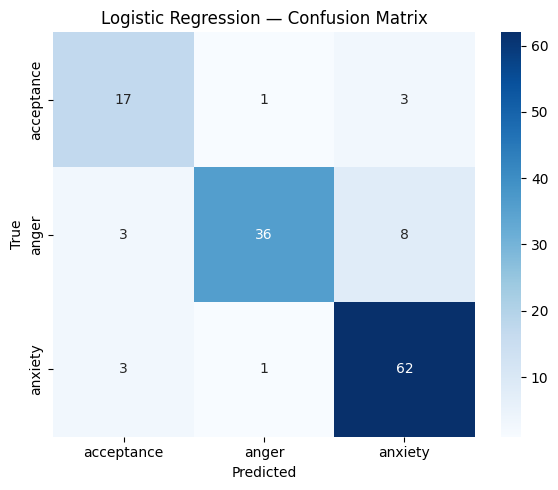

Logistic Regression - Test Acc: 0.8582, F1: 0.8576


In [40]:
# Logistic Regression
logreg_model = model_LogisticRegression()

print("="*50)
print(" Logistic Regression ")
print("="*50)

test_acc_logreg, test_f1_logreg = evaluate_sklearn_model(logreg_model, X_test_tfidf, y_test, "Logistic Regression")
print(f'Logistic Regression - Test Acc: {test_acc_logreg:.4f}, F1: {test_f1_logreg:.4f}')

 LinearSVC 

LinearSVC — Accuracy: 0.8731 | F1: 0.8725
              precision    recall  f1-score   support

  acceptance       0.75      0.71      0.73        21
       anger       0.95      0.85      0.90        47
     anxiety       0.86      0.94      0.90        66

    accuracy                           0.87       134
   macro avg       0.85      0.83      0.84       134
weighted avg       0.88      0.87      0.87       134



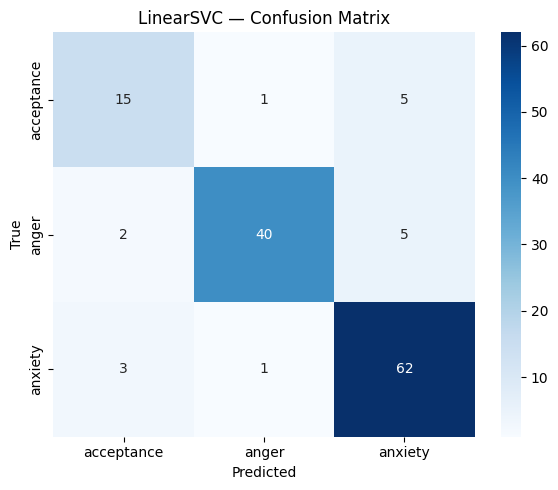

LinearSVC - Test Acc: 0.8731, F1: 0.8725


In [41]:
# LinearSVC
linearsvc_model = model_LinearSVC()

print("="*50)
print(" LinearSVC ")
print("="*50)

test_acc_linearsvc, test_f1_linearsvc = evaluate_sklearn_model(linearsvc_model, X_test_tfidf, y_test, "LinearSVC")
print(f'LinearSVC - Test Acc: {test_acc_linearsvc:.4f}, F1: {test_f1_linearsvc:.4f}')

 Multinomial Naive Bayes 

Multinomial Naive Bayes — Accuracy: 0.8209 | F1: 0.8209
              precision    recall  f1-score   support

  acceptance       0.71      0.71      0.71        21
       anger       0.83      0.83      0.83        47
     anxiety       0.85      0.85      0.85        66

    accuracy                           0.82       134
   macro avg       0.80      0.80      0.80       134
weighted avg       0.82      0.82      0.82       134



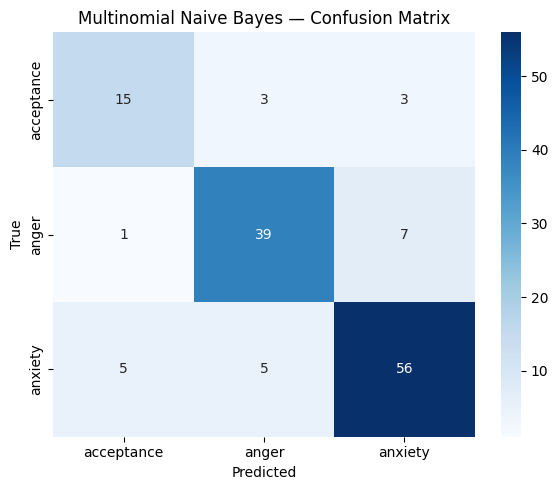

Multinomial Naive Bayes - Test Acc: 0.8209, F1: 0.8209


In [42]:
# Multinomial Naive Bayes
mnb_model = model_MultinomialNB()

print("="*50)
print(" Multinomial Naive Bayes ")
print("="*50)

test_acc_mnb, test_f1_mnb = evaluate_sklearn_model(mnb_model, X_test_count, y_test, "Multinomial Naive Bayes")
print(f'Multinomial Naive Bayes - Test Acc: {test_acc_mnb:.4f}, F1: {test_f1_mnb:.4f}')

 Random Forest 

Random Forest — Accuracy: 0.9030 | F1: 0.8969
              precision    recall  f1-score   support

  acceptance       1.00      0.57      0.73        21
       anger       0.98      0.91      0.95        47
     anxiety       0.85      1.00      0.92        66

    accuracy                           0.90       134
   macro avg       0.94      0.83      0.86       134
weighted avg       0.92      0.90      0.90       134



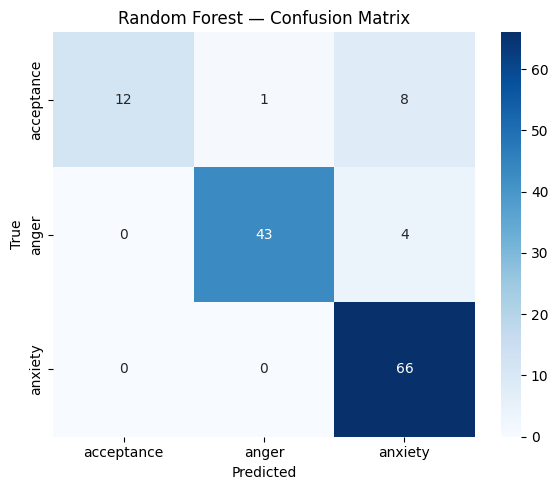

Random Forest - Test Acc: 0.9030, F1: 0.8969


In [43]:
# Random Forest
rf_model = model_RandomForest()

print("="*50)
print(" Random Forest ")
print("="*50)

test_acc_rf, test_f1_rf = evaluate_sklearn_model(rf_model, X_test_tfidf, y_test, "Random Forest")
print(f'Random Forest - Test Acc: {test_acc_rf:.4f}, F1: {test_f1_rf:.4f}')

 LSTM 

  Training: LSTM
Epoch 01/50 | loss: 1.1026 | acc: 0.3277 | val_loss: 1.0931 | val_acc: 0.4851
  ✅ val_accuracy meningkat → model disimpan (0.4851)
Epoch 02/50 | loss: 1.1054 | acc: 0.3305 | val_loss: 1.0920 | val_acc: 0.1567
Epoch 03/50 | loss: 1.0966 | acc: 0.3418 | val_loss: 1.0946 | val_acc: 0.3657
Epoch 04/50 | loss: 1.0967 | acc: 0.4064 | val_loss: 1.0827 | val_acc: 0.1567
Epoch 05/50 | loss: 1.1157 | acc: 0.3361 | val_loss: 1.0834 | val_acc: 0.3731
Epoch 06/50 | loss: 1.0926 | acc: 0.3998 | val_loss: 1.0744 | val_acc: 0.4925
  ✅ val_accuracy meningkat → model disimpan (0.4925)
Epoch 07/50 | loss: 1.0801 | acc: 0.4007 | val_loss: 1.0708 | val_acc: 0.4925
Epoch 08/50 | loss: 1.0707 | acc: 0.3614 | val_loss: 1.0684 | val_acc: 0.4925
Epoch 09/50 | loss: 1.0553 | acc: 0.4532 | val_loss: 1.0650 | val_acc: 0.4925
Epoch 10/50 | loss: 1.0582 | acc: 0.4691 | val_loss: 1.0699 | val_acc: 0.3731
Epoch 11/50 | loss: 1.0597 | acc: 0.3904 | val_loss: 1.0656 | val_acc: 0.4776
  ⏹ Early s

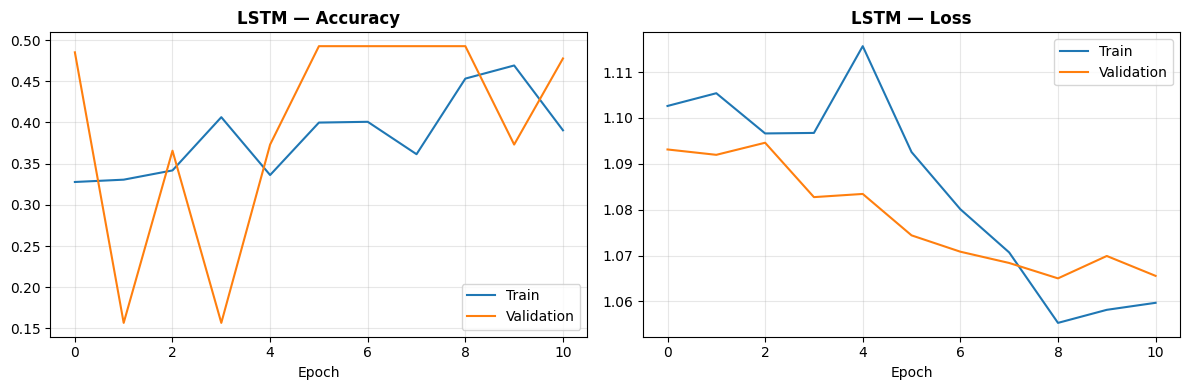


──────────────────────────────────────────────────
LSTM — Test Accuracy: 0.5224 | F1: 0.3855 | MAE: 0.4294
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  acceptance       1.00      0.14      0.25        21
       anger       1.00      0.02      0.04        47
     anxiety       0.51      1.00      0.67        66

    accuracy                           0.52       134
   macro avg       0.84      0.39      0.32       134
weighted avg       0.76      0.52      0.39       134



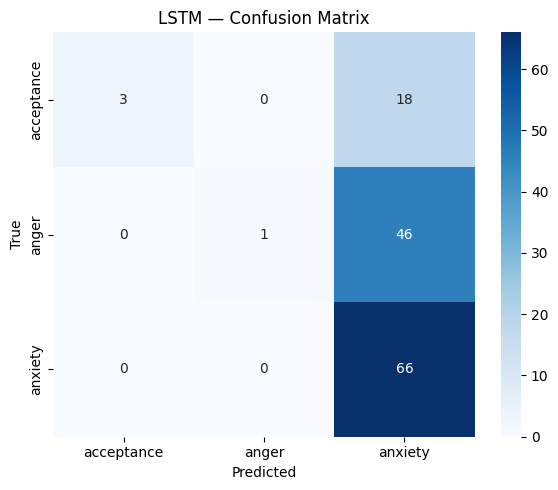

LSTM — Best Epoch: 6 | Train Acc: 0.3998 | Val Acc: 0.4925 | Test Acc: 0.5224 | MAE: 0.4294


In [44]:
# ── LSTM ──────────────────────────────────────────────────────
lstm_model = model_LSTM()

print("=" * 50)
print(" LSTM ")
print("=" * 50)

lstm_model, lstm_history = train_model(lstm_model, 'LSTM', X_train_seq, y_train, X_val_seq, y_val)

plot_history(lstm_history, 'LSTM')

best_epoch_lstm  = int(np.argmax(lstm_history['val_accuracy'])) + 1
train_acc_lstm   = lstm_history['accuracy'][best_epoch_lstm - 1]
val_acc_lstm     = lstm_history['val_accuracy'][best_epoch_lstm - 1]
test_acc_lstm, test_f1_lstm, test_mae_lstm = evaluate_dl_model(lstm_model, X_test_seq, y_test, 'LSTM')

print(f'LSTM — Best Epoch: {best_epoch_lstm} | Train Acc: {train_acc_lstm:.4f} | Val Acc: {val_acc_lstm:.4f} | Test Acc: {test_acc_lstm:.4f} | MAE: {test_mae_lstm:.4f}')

 GRU 

  Training: GRU
Epoch 01/50 | loss: 1.1034 | acc: 0.3605 | val_loss: 1.0911 | val_acc: 0.4851
  ✅ val_accuracy meningkat → model disimpan (0.4851)
Epoch 02/50 | loss: 1.1036 | acc: 0.2949 | val_loss: 1.0889 | val_acc: 0.4851
Epoch 03/50 | loss: 1.0991 | acc: 0.3399 | val_loss: 1.0896 | val_acc: 0.1642
Epoch 04/50 | loss: 1.0923 | acc: 0.3886 | val_loss: 1.0835 | val_acc: 0.1642
Epoch 05/50 | loss: 1.0875 | acc: 0.3483 | val_loss: 1.0851 | val_acc: 0.1642
Epoch 06/50 | loss: 1.0725 | acc: 0.3558 | val_loss: 1.0703 | val_acc: 0.3731
  ⏹ Early stopping epoch 6. Best epoch: 1

📊 TensorBoard logs disimpan di: ./logs\GRU
   Jalankan: tensorboard --logdir ./logs\GRU
✅ GRU selesai. Best val_acc: 0.4851 (epoch 1)


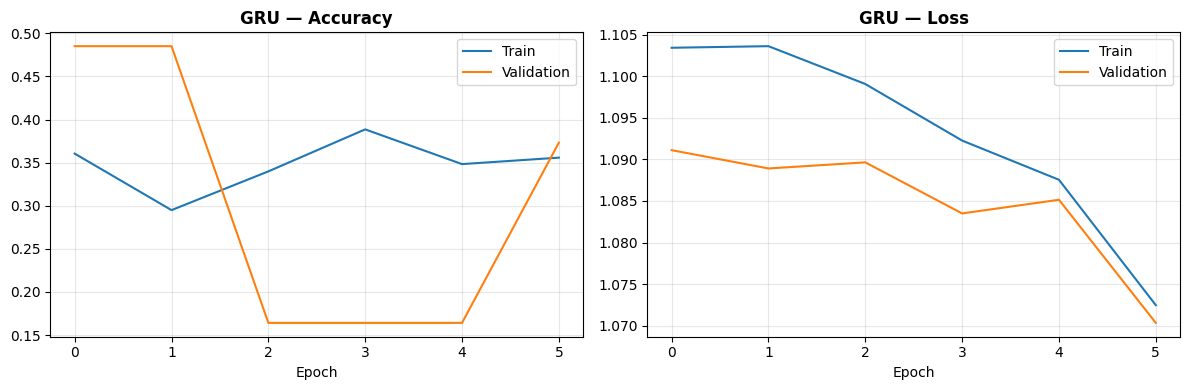


──────────────────────────────────────────────────
GRU — Test Accuracy: 0.3806 | F1: 0.2402 | MAE: 0.4314
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  acceptance       1.00      0.14      0.25        21
       anger       0.36      1.00      0.53        47
     anxiety       1.00      0.02      0.03        66

    accuracy                           0.38       134
   macro avg       0.79      0.39      0.27       134
weighted avg       0.78      0.38      0.24       134



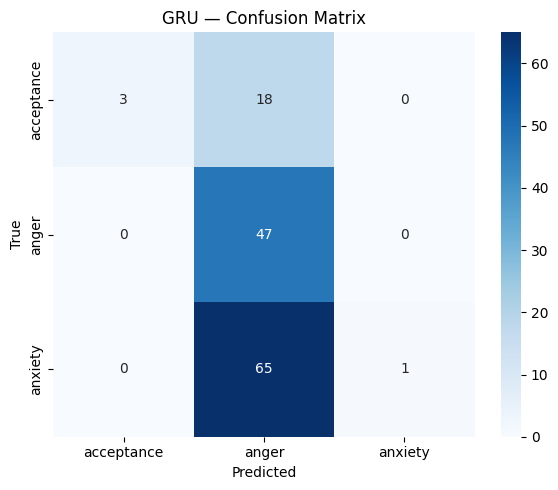

GRU — Best Epoch: 1 | Train Acc: 0.3605 | Val Acc: 0.4851 | Test Acc: 0.3806 | MAE: 0.4314


In [45]:
# ── GRU ───────────────────────────────────────────────────────
gru_model = model_GRU()

print("=" * 50)
print(" GRU ")
print("=" * 50)

gru_model, gru_history = train_model(gru_model, 'GRU', X_train_seq, y_train, X_val_seq, y_val)

plot_history(gru_history, 'GRU')

best_epoch_gru  = int(np.argmax(gru_history['val_accuracy'])) + 1
train_acc_gru   = gru_history['accuracy'][best_epoch_gru - 1]
val_acc_gru     = gru_history['val_accuracy'][best_epoch_gru - 1]
test_acc_gru, test_f1_gru, test_mae_gru = evaluate_dl_model(gru_model, X_test_seq, y_test, 'GRU')

print(f'GRU — Best Epoch: {best_epoch_gru} | Train Acc: {train_acc_gru:.4f} | Val Acc: {val_acc_gru:.4f} | Test Acc: {test_acc_gru:.4f} | MAE: {test_mae_gru:.4f}')

 CNN 

  Training: CNN
Epoch 01/50 | loss: 1.0745 | acc: 0.3830 | val_loss: 1.0250 | val_acc: 0.5821
  ✅ val_accuracy meningkat → model disimpan (0.5821)
Epoch 02/50 | loss: 0.9868 | acc: 0.4794 | val_loss: 0.9437 | val_acc: 0.6045
  ✅ val_accuracy meningkat → model disimpan (0.6045)
Epoch 03/50 | loss: 0.8176 | acc: 0.6704 | val_loss: 0.8095 | val_acc: 0.7388
  ✅ val_accuracy meningkat → model disimpan (0.7388)
Epoch 04/50 | loss: 0.5424 | acc: 0.8371 | val_loss: 0.6107 | val_acc: 0.8060
  ✅ val_accuracy meningkat → model disimpan (0.8060)
Epoch 05/50 | loss: 0.2853 | acc: 0.9335 | val_loss: 0.4424 | val_acc: 0.8881
  ✅ val_accuracy meningkat → model disimpan (0.8881)
Epoch 06/50 | loss: 0.1487 | acc: 0.9775 | val_loss: 0.3783 | val_acc: 0.8806
Epoch 07/50 | loss: 0.0925 | acc: 0.9841 | val_loss: 0.3351 | val_acc: 0.8657
Epoch 08/50 | loss: 0.0431 | acc: 0.9963 | val_loss: 0.2941 | val_acc: 0.8806
Epoch 09/50 | loss: 0.0345 | acc: 0.9916 | val_loss: 0.2848 | val_acc: 0.8881
Epoch 10/5

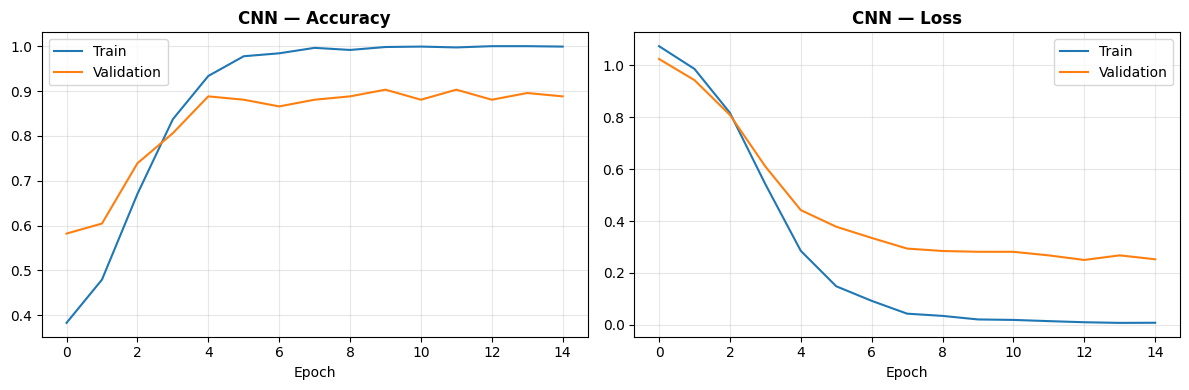


──────────────────────────────────────────────────
CNN — Test Accuracy: 0.9403 | F1: 0.9402 | MAE: 0.0706
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  acceptance       0.86      0.86      0.86        21
       anger       0.96      0.98      0.97        47
     anxiety       0.95      0.94      0.95        66

    accuracy                           0.94       134
   macro avg       0.92      0.93      0.92       134
weighted avg       0.94      0.94      0.94       134



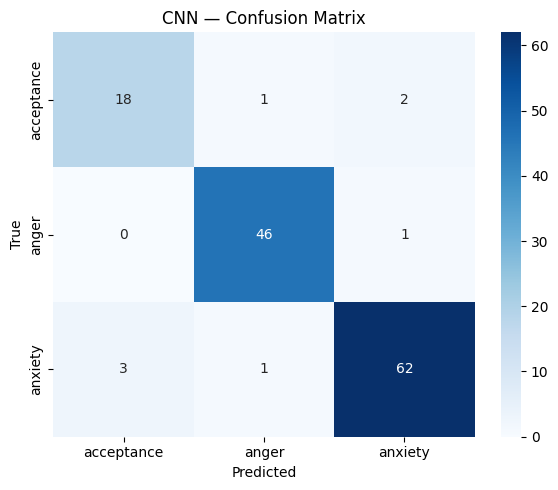

CNN — Best Epoch: 10 | Train Acc: 0.9981 | Val Acc: 0.9030 | Test Acc: 0.9403 | MAE: 0.0706


In [46]:
# ── CNN ───────────────────────────────────────────────────────
cnn_model = model_CNN()

print("=" * 50)
print(" CNN ")
print("=" * 50)

cnn_model, cnn_history = train_model(cnn_model, 'CNN', X_train_seq, y_train, X_val_seq, y_val)

plot_history(cnn_history, 'CNN')

best_epoch_cnn  = int(np.argmax(cnn_history['val_accuracy'])) + 1
train_acc_cnn   = cnn_history['accuracy'][best_epoch_cnn - 1]
val_acc_cnn     = cnn_history['val_accuracy'][best_epoch_cnn - 1]
test_acc_cnn, test_f1_cnn, test_mae_cnn = evaluate_dl_model(cnn_model, X_test_seq, y_test, 'CNN')

print(f'CNN — Best Epoch: {best_epoch_cnn} | Train Acc: {train_acc_cnn:.4f} | Val Acc: {val_acc_cnn:.4f} | Test Acc: {test_acc_cnn:.4f} | MAE: {test_mae_cnn:.4f}')

 BiLSTM 

  Training: BiLSTM
Epoch 01/50 | loss: 1.0883 | acc: 0.3764 | val_loss: 1.0684 | val_acc: 0.4627
  ✅ val_accuracy meningkat → model disimpan (0.4627)
Epoch 02/50 | loss: 1.0291 | acc: 0.4560 | val_loss: 0.9798 | val_acc: 0.5896
  ✅ val_accuracy meningkat → model disimpan (0.5896)
Epoch 03/50 | loss: 0.8875 | acc: 0.5674 | val_loss: 0.8206 | val_acc: 0.5970
  ✅ val_accuracy meningkat → model disimpan (0.5970)
Epoch 04/50 | loss: 0.5348 | acc: 0.7818 | val_loss: 0.6917 | val_acc: 0.7313
  ✅ val_accuracy meningkat → model disimpan (0.7313)
Epoch 05/50 | loss: 0.2927 | acc: 0.8998 | val_loss: 0.5550 | val_acc: 0.8433
  ✅ val_accuracy meningkat → model disimpan (0.8433)
Epoch 06/50 | loss: 0.1872 | acc: 0.9504 | val_loss: 0.4729 | val_acc: 0.8358
Epoch 07/50 | loss: 0.0771 | acc: 0.9860 | val_loss: 0.4706 | val_acc: 0.8284
Epoch 08/50 | loss: 0.0457 | acc: 0.9897 | val_loss: 0.6818 | val_acc: 0.8358
Epoch 09/50 | loss: 0.0380 | acc: 0.9916 | val_loss: 0.5776 | val_acc: 0.8433
Epoc

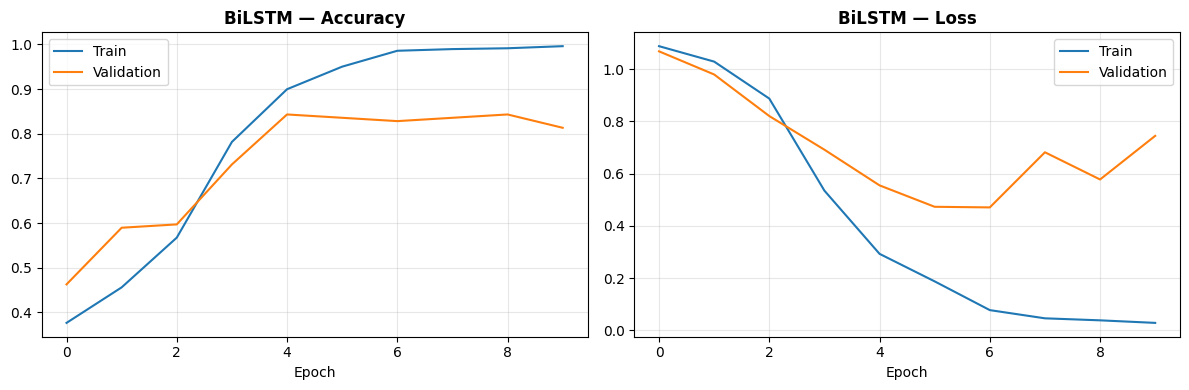


──────────────────────────────────────────────────
BiLSTM — Test Accuracy: 0.8358 | F1: 0.8363 | MAE: 0.1199
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  acceptance       0.65      0.71      0.68        21
       anger       0.88      0.79      0.83        47
     anxiety       0.87      0.91      0.89        66

    accuracy                           0.84       134
   macro avg       0.80      0.80      0.80       134
weighted avg       0.84      0.84      0.84       134



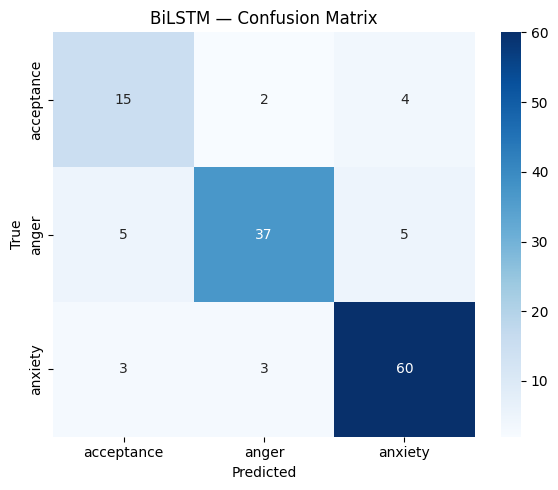

BiLSTM — Best Epoch: 5 | Train Acc: 0.8998 | Val Acc: 0.8433 | Test Acc: 0.8358 | MAE: 0.1199


In [47]:
# ── BiLSTM ────────────────────────────────────────────────────
bilstm_model = model_BiLSTM()

print("=" * 50)
print(" BiLSTM ")
print("=" * 50)

bilstm_model, bilstm_history = train_model(bilstm_model, 'BiLSTM', X_train_seq, y_train, X_val_seq, y_val)

plot_history(bilstm_history, 'BiLSTM')

best_epoch_bilstm  = int(np.argmax(bilstm_history['val_accuracy'])) + 1
train_acc_bilstm   = bilstm_history['accuracy'][best_epoch_bilstm - 1]
val_acc_bilstm     = bilstm_history['val_accuracy'][best_epoch_bilstm - 1]
test_acc_bilstm, test_f1_bilstm, test_mae_bilstm = evaluate_dl_model(bilstm_model, X_test_seq, y_test, 'BiLSTM')

print(f'BiLSTM — Best Epoch: {best_epoch_bilstm} | Train Acc: {train_acc_bilstm:.4f} | Val Acc: {val_acc_bilstm:.4f} | Test Acc: {test_acc_bilstm:.4f} | MAE: {test_mae_bilstm:.4f}')

In [ ]:
# ── CNN + BiLSTM ──────────────────────────────────────────────
cnn_bilstm_model = model_CNN_BiLSTM()

print("=" * 50)
print(" CNN + BiLSTM ")
print("=" * 50)

cnn_bilstm_model, cnn_bilstm_history = train_model(cnn_bilstm_model, 'CNN_BiLSTM', X_train_seq, y_train, X_val_seq, y_val)

plot_history(cnn_bilstm_history, 'CNN + BiLSTM')

best_epoch_cnn_bilstm  = int(np.argmax(cnn_bilstm_history['val_accuracy'])) + 1
train_acc_cnn_bilstm   = cnn_bilstm_history['accuracy'][best_epoch_cnn_bilstm - 1]
val_acc_cnn_bilstm     = cnn_bilstm_history['val_accuracy'][best_epoch_cnn_bilstm - 1]
test_acc_cnn_bilstm, test_f1_cnn_bilstm, test_mae_cnn_bilstm = evaluate_dl_model(cnn_bilstm_model, X_test_seq, y_test, 'CNN + BiLSTM')

print(f'CNN + BiLSTM — Best Epoch: {best_epoch_cnn_bilstm} | Train Acc: {train_acc_cnn_bilstm:.4f} | Val Acc: {val_acc_cnn_bilstm:.4f} | Test Acc: {test_acc_cnn_bilstm:.4f} | MAE: {test_mae_cnn_bilstm:.4f}')

 CNN + BiLSTM 

  Training: CNN_BiLSTM
Epoch 01/50 | loss: 1.0692 | acc: 0.3717 | val_loss: 0.9446 | val_acc: 0.4030
  ✅ val_accuracy meningkat → model disimpan (0.4030)
Epoch 02/50 | loss: 0.9267 | acc: 0.4607 | val_loss: 0.8249 | val_acc: 0.5075
  ✅ val_accuracy meningkat → model disimpan (0.5075)
Epoch 03/50 | loss: 0.6044 | acc: 0.6919 | val_loss: 0.6905 | val_acc: 0.6716
  ✅ val_accuracy meningkat → model disimpan (0.6716)
Epoch 04/50 | loss: 0.3292 | acc: 0.8446 | val_loss: 0.5665 | val_acc: 0.7910
  ✅ val_accuracy meningkat → model disimpan (0.7910)
Epoch 05/50 | loss: 0.1501 | acc: 0.9382 | val_loss: 0.6691 | val_acc: 0.7910
Epoch 06/50 | loss: 0.0477 | acc: 0.9888 | val_loss: 0.9213 | val_acc: 0.8284
  ✅ val_accuracy meningkat → model disimpan (0.8284)
Epoch 07/50 | loss: 0.0543 | acc: 0.9775 | val_loss: 0.6247 | val_acc: 0.8209
Epoch 08/50 | loss: 0.0258 | acc: 0.9934 | val_loss: 0.6611 | val_acc: 0.8209



 CNN + BiLSTM + BatchNorm 
Training CNN_BiLSTM_BN...
Epoch 01/50 - loss: 1.0771 - accuracy: 0.4139 - val_loss: 1.0846 - val_accuracy: 0.3507
Epoch 02/50 - loss: 0.8337 - accuracy: 0.6208 - val_loss: 1.0604 - val_accuracy: 0.3507
Epoch 03/50 - loss: 0.5635 - accuracy: 0.7650 - val_loss: 1.0153 - val_accuracy: 0.5075
Epoch 04/50 - loss: 0.2460 - accuracy: 0.9045 - val_loss: 0.9383 - val_accuracy: 0.6791
Epoch 05/50 - loss: 0.1255 - accuracy: 0.9644 - val_loss: 0.8274 - val_accuracy: 0.7164
Epoch 06/50 - loss: 0.0690 - accuracy: 0.9794 - val_loss: 0.8507 - val_accuracy: 0.6866
Epoch 07/50 - loss: 0.0581 - accuracy: 0.9813 - val_loss: 0.7650 - val_accuracy: 0.6866
Epoch 08/50 - loss: 0.0341 - accuracy: 0.9953 - val_loss: 1.0620 - val_accuracy: 0.6791
Epoch 09/50 - loss: 0.0222 - accuracy: 0.9953 - val_loss: 0.7849 - val_accuracy: 0.7612
Epoch 10/50 - loss: 0.0099 - accuracy: 0.9981 - val_loss: 0.8523 - val_accuracy: 0.8060
Epoch 11/50 - loss: 0.0059 - accuracy: 1.0000 - val_loss: 0.8733 -

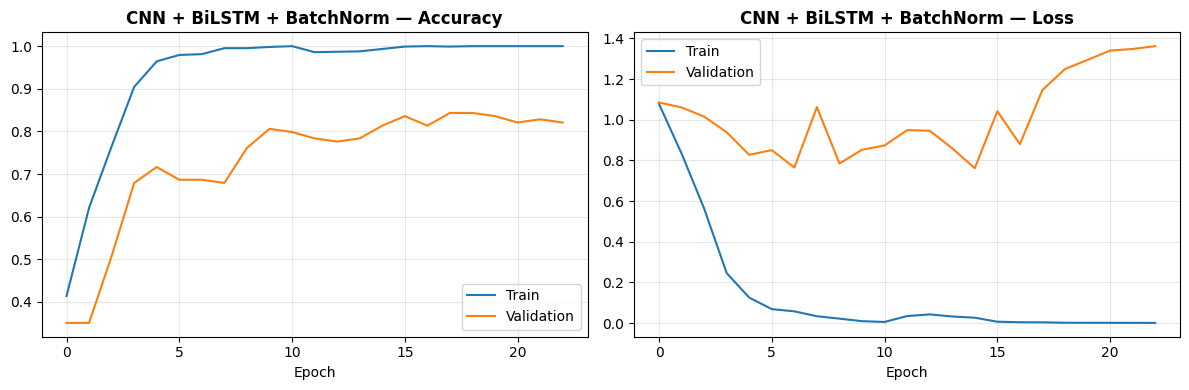


CNN + BiLSTM + BatchNorm — Loss: 0.8250, Accuracy: 0.8657, F1-Score: 0.8643
              precision    recall  f1-score   support

  acceptance       0.80      0.76      0.78        21
       anger       0.95      0.79      0.86        47
     anxiety       0.84      0.95      0.89        66

    accuracy                           0.87       134
   macro avg       0.86      0.83      0.84       134
weighted avg       0.87      0.87      0.86       134



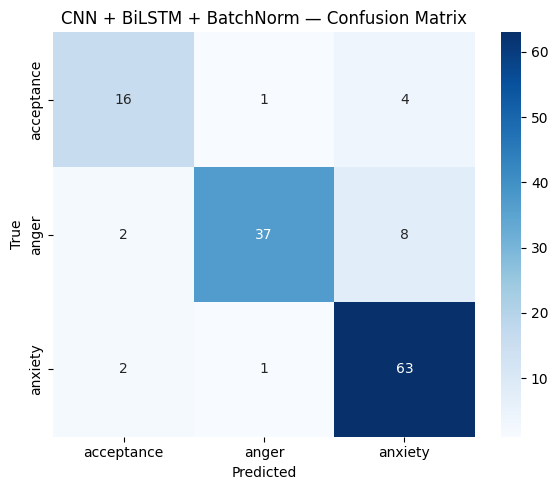

CNN+BiLSTM+BN - Best Epoch: 18, Train Acc: 0.9991, Val Acc: 0.8433, Test Acc: 0.8657


In [ ]:
# ── CNN + BiLSTM + BatchNorm ──────────────────────────────────
cnn_bilstm_bn_model = model_CNN_BiLSTM_BatchNorm()

print("=" * 50)
print(" CNN + BiLSTM + BatchNorm ")
print("=" * 50)

cnn_bilstm_bn_model, cnn_bilstm_bn_history = train_model(cnn_bilstm_bn_model, 'CNN_BiLSTM_BN', X_train_seq, y_train, X_val_seq, y_val)

plot_history(cnn_bilstm_bn_history, 'CNN + BiLSTM + BatchNorm')

best_epoch_cnn_bilstm_bn  = int(np.argmax(cnn_bilstm_bn_history['val_accuracy'])) + 1
train_acc_cnn_bilstm_bn   = cnn_bilstm_bn_history['accuracy'][best_epoch_cnn_bilstm_bn - 1]
val_acc_cnn_bilstm_bn     = cnn_bilstm_bn_history['val_accuracy'][best_epoch_cnn_bilstm_bn - 1]
test_acc_cnn_bilstm_bn, test_f1_cnn_bilstm_bn, test_mae_cnn_bilstm_bn = evaluate_dl_model(cnn_bilstm_bn_model, X_test_seq, y_test, 'CNN + BiLSTM + BatchNorm')

print(f'CNN + BiLSTM + BN — Best Epoch: {best_epoch_cnn_bilstm_bn} | Train Acc: {train_acc_cnn_bilstm_bn:.4f} | Val Acc: {val_acc_cnn_bilstm_bn:.4f} | Test Acc: {test_acc_cnn_bilstm_bn:.4f} | MAE: {test_mae_cnn_bilstm_bn:.4f}')

In [ ]:
# ── BiLSTM + Attention ────────────────────────────────────────
bilstm_att_model = model_BiLSTM_Attention()

print("=" * 50)
print(" BiLSTM + Attention ")
print("=" * 50)

bilstm_att_model, bilstm_att_history = train_model(bilstm_att_model, 'BiLSTM_Attention', X_train_seq, y_train, X_val_seq, y_val)

plot_history(bilstm_att_history, 'BiLSTM + Attention')

best_epoch_bilstm_att  = int(np.argmax(bilstm_att_history['val_accuracy'])) + 1
train_acc_bilstm_att   = bilstm_att_history['accuracy'][best_epoch_bilstm_att - 1]
val_acc_bilstm_att     = bilstm_att_history['val_accuracy'][best_epoch_bilstm_att - 1]
test_acc_bilstm_att, test_f1_bilstm_att, test_mae_bilstm_att = evaluate_dl_model(bilstm_att_model, X_test_seq, y_test, 'BiLSTM + Attention')

print(f'BiLSTM + Attention — Best Epoch: {best_epoch_bilstm_att} | Train Acc: {train_acc_bilstm_att:.4f} | Val Acc: {val_acc_bilstm_att:.4f} | Test Acc: {test_acc_bilstm_att:.4f} | MAE: {test_mae_bilstm_att:.4f}')

In [ ]:
# ── CNN Multi-Kernel ──────────────────────────────────────────
cnn_mk_model = model_CNN_MultiKernel()

print("=" * 50)
print(" CNN Multi-Kernel ")
print("=" * 50)

cnn_mk_model, cnn_mk_history = train_model(cnn_mk_model, 'CNN_MultiKernel', X_train_seq, y_train, X_val_seq, y_val)

plot_history(cnn_mk_history, 'CNN Multi-Kernel')

best_epoch_cnn_mk  = int(np.argmax(cnn_mk_history['val_accuracy'])) + 1
train_acc_cnn_mk   = cnn_mk_history['accuracy'][best_epoch_cnn_mk - 1]
val_acc_cnn_mk     = cnn_mk_history['val_accuracy'][best_epoch_cnn_mk - 1]
test_acc_cnn_mk, test_f1_cnn_mk, test_mae_cnn_mk = evaluate_dl_model(cnn_mk_model, X_test_seq, y_test, 'CNN Multi-Kernel')

print(f'CNN Multi-Kernel — Best Epoch: {best_epoch_cnn_mk} | Train Acc: {train_acc_cnn_mk:.4f} | Val Acc: {val_acc_cnn_mk:.4f} | Test Acc: {test_acc_cnn_mk:.4f} | MAE: {test_mae_cnn_mk:.4f}')

In [ ]:
# ── BiGRU + Attention ─────────────────────────────────────────
bigru_att_model = model_BiGRU_Attention()

print("=" * 50)
print(" BiGRU + Attention ")
print("=" * 50)

bigru_att_model, bigru_att_history = train_model(bigru_att_model, 'BiGRU_Attention', X_train_seq, y_train, X_val_seq, y_val)

plot_history(bigru_att_history, 'BiGRU + Attention')

best_epoch_bigru_att  = int(np.argmax(bigru_att_history['val_accuracy'])) + 1
train_acc_bigru_att   = bigru_att_history['accuracy'][best_epoch_bigru_att - 1]
val_acc_bigru_att     = bigru_att_history['val_accuracy'][best_epoch_bigru_att - 1]
test_acc_bigru_att, test_f1_bigru_att, test_mae_bigru_att = evaluate_dl_model(bigru_att_model, X_test_seq, y_test, 'BiGRU + Attention')

print(f'BiGRU + Attention — Best Epoch: {best_epoch_bigru_att} | Train Acc: {train_acc_bigru_att:.4f} | Val Acc: {val_acc_bigru_att:.4f} | Test Acc: {test_acc_bigru_att:.4f} | MAE: {test_mae_bigru_att:.4f}')

In [ ]:
# ── CNN + BiLSTM + Attention ──────────────────────────────────
cnn_bilstm_att_model = model_CNN_BiLSTM_Attention()

print("=" * 50)
print(" CNN + BiLSTM + Attention ")
print("=" * 50)

cnn_bilstm_att_model, cnn_bilstm_att_history = train_model(cnn_bilstm_att_model, 'CNN_BiLSTM_Attention', X_train_seq, y_train, X_val_seq, y_val)

plot_history(cnn_bilstm_att_history, 'CNN + BiLSTM + Attention')

best_epoch_cnn_bilstm_att  = int(np.argmax(cnn_bilstm_att_history['val_accuracy'])) + 1
train_acc_cnn_bilstm_att   = cnn_bilstm_att_history['accuracy'][best_epoch_cnn_bilstm_att - 1]
val_acc_cnn_bilstm_att     = cnn_bilstm_att_history['val_accuracy'][best_epoch_cnn_bilstm_att - 1]
test_acc_cnn_bilstm_att, test_f1_cnn_bilstm_att, test_mae_cnn_bilstm_att = evaluate_dl_model(cnn_bilstm_att_model, X_test_seq, y_test, 'CNN + BiLSTM + Attention')

print(f'CNN + BiLSTM + Attention — Best Epoch: {best_epoch_cnn_bilstm_att} | Train Acc: {train_acc_cnn_bilstm_att:.4f} | Val Acc: {val_acc_cnn_bilstm_att:.4f} | Test Acc: {test_acc_cnn_bilstm_att:.4f} | MAE: {test_mae_cnn_bilstm_att:.4f}')

In [ ]:
# ── Stacked BiLSTM ────────────────────────────────────────────
stacked_bilstm_model = model_StackedBiLSTM()

print("=" * 50)
print(" Stacked BiLSTM ")
print("=" * 50)

stacked_bilstm_model, stacked_bilstm_history = train_model(stacked_bilstm_model, 'StackedBiLSTM', X_train_seq, y_train, X_val_seq, y_val)

plot_history(stacked_bilstm_history, 'Stacked BiLSTM')

best_epoch_stacked_bilstm  = int(np.argmax(stacked_bilstm_history['val_accuracy'])) + 1
train_acc_stacked_bilstm   = stacked_bilstm_history['accuracy'][best_epoch_stacked_bilstm - 1]
val_acc_stacked_bilstm     = stacked_bilstm_history['val_accuracy'][best_epoch_stacked_bilstm - 1]
test_acc_stacked_bilstm, test_f1_stacked_bilstm, test_mae_stacked_bilstm = evaluate_dl_model(stacked_bilstm_model, X_test_seq, y_test, 'Stacked BiLSTM')

print(f'Stacked BiLSTM — Best Epoch: {best_epoch_stacked_bilstm} | Train Acc: {train_acc_stacked_bilstm:.4f} | Val Acc: {val_acc_stacked_bilstm:.4f} | Test Acc: {test_acc_stacked_bilstm:.4f} | MAE: {test_mae_stacked_bilstm:.4f}')

## Evaluasi dan Metrics

In [ ]:
print("=" * 50)
print(" Evaluasi Akhir ")
print("=" * 50)

models_info = [
    ('Logistic Regression',        test_acc_logreg),
    ('LinearSVC',                  test_acc_linearsvc),
    ('Multinomial Naive Bayes',    test_acc_mnb),
    ('Random Forest',              test_acc_rf),
    ('LSTM',                       test_acc_lstm),
    ('GRU',                        test_acc_gru),
    ('CNN',                        test_acc_cnn),
    ('BiLSTM',                     test_acc_bilstm),
    ('CNN + BiLSTM',               test_acc_cnn_bilstm),
    ('CNN + BiLSTM + BatchNorm',   test_acc_cnn_bilstm_bn),
    ('BiLSTM + Attention',         test_acc_bilstm_att),
    ('CNN Multi-Kernel',           test_acc_cnn_mk),
    ('BiGRU + Attention',          test_acc_bigru_att),
    ('CNN + BiLSTM + Attention',   test_acc_cnn_bilstm_att),
    ('Stacked BiLSTM',             test_acc_stacked_bilstm),
]

print(f'{"Model":35s} | {"Test Accuracy":>12s}')
print("-" * 50)

for name, acc in models_info:
    print(f'{name:35s} | {acc:.4f}')

best_model_info = max(models_info, key=lambda x: x[1])
print("\nModel terbaik:", best_model_info[0], f"({best_model_info[1]:.4f})")

 Evaluasi Akhir 
Model                               | Test Accuracy
--------------------------------------------------
Logistic Regression                 | 0.8582
LinearSVC                           | 0.8731
Multinomial Naive Bayes             | 0.8209
Random Forest                       | 0.9030
LSTM                                | 0.5075
GRU                                 | 0.5075
CNN                                 | 0.8209
BiLSTM                              | 0.8955
CNN + BiLSTM                        | 0.8806
CNN + BiLSTM + BatchNorm            | 0.8657

Model terbaik: Random Forest (0.9030)


## Perbandingan

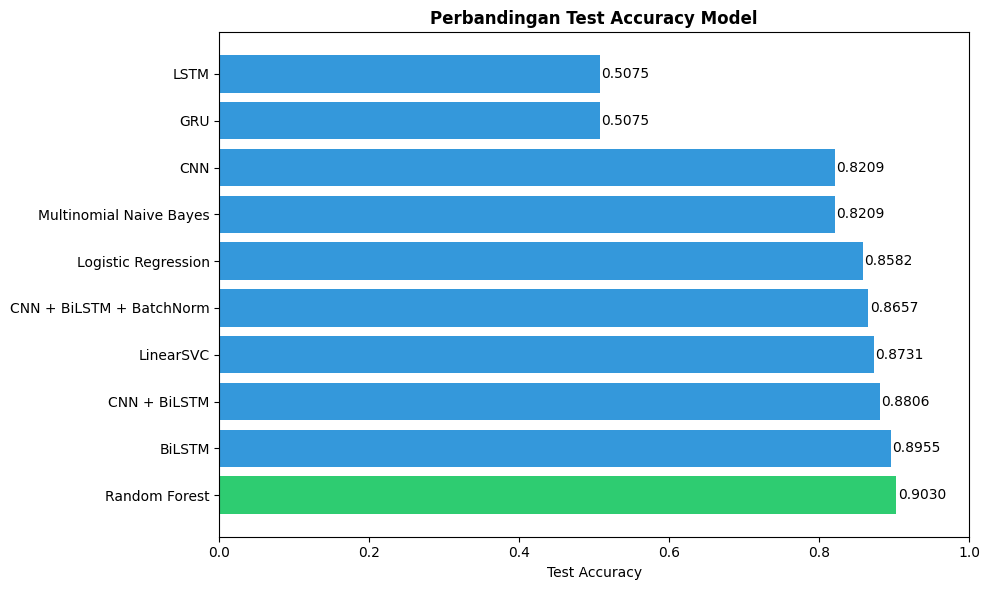

Model terbaik: Random Forest (0.9030)


In [ ]:
# Perbandingan performa model dan tampilkan model terbaik
df_results = pd.DataFrame(models_info, columns=['Model', 'TestAccuracy']).sort_values('TestAccuracy', ascending=False).reset_index(drop=True)

best = df_results.iloc[0]

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if m == best['Model'] else '#3498db' for m in df_results['Model']]
bars = plt.barh(df_results['Model'], df_results['TestAccuracy'], color=colors)
for i, acc in enumerate(df_results['TestAccuracy']):
    plt.text(acc + 0.002, i, f'{acc:.4f}', va='center')
plt.title('Perbandingan Test Accuracy Model', fontweight='bold')
plt.xlabel('Test Accuracy')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(f"Model terbaik: {best['Model']} ({best['TestAccuracy']:.4f})")